In [2]:
import matplotlib
import numpy as np

from matplotlib import pyplot as plt
from model_tools import ModelAnalysis, RasterAnalysis, make_image

#Set plotting look and feel

host_color = matplotlib.colors.to_rgb('#0000a2')
path_color = matplotlib.colors.to_rgb('#bc272d')
coevol_color = matplotlib.colors.to_rgb('#e9c716')
coevol_color_2 = matplotlib.colors.to_rgb('#50ad9f')

s_cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", ["white", host_color])
i_cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", ["white", path_color])

plot_label_size = 10
axis_title_size = 10
axis_label_size = 6
tick_label_size = 6

matplotlib.rcParams['axes.titlesize'] = axis_title_size
matplotlib.rcParams['axes.labelsize'] = axis_label_size
matplotlib.rcParams['xtick.labelsize'] = tick_label_size
matplotlib.rcParams['ytick.labelsize'] = tick_label_size

matplotlib.rcParams['figure.dpi'] = 300
matplotlib.rcParams['text.usetex'] = True
matplotlib.rcParams['text.latex.preamble'] = r'\usepackage{xfrac}'

plt.rcParams.update({
    'text.usetex': True,
    'font.family': 'Helvetica'
})

# Figure 1: Categories of evolutionary dynamics and outcomes #

In [3]:
params = {'m':0.75, 'z':5, 'mu':0.2, 'juv_trans':False, 'N_iter':200,'S_gtp0':50, 'I_gtp0':50}

model_host = ModelAnalysis(mode='host', **params)
model_path = ModelAnalysis(mode='path', **params)
model_coevol = ModelAnalysis(mode='coevol', **params)

Sa_img_host, Ia_img_host, Sa_alpha_host, Ia_alpha_host = make_image(model_host.Sa, model_host.Ia)
Sa_img_path, Ia_img_path, Sa_alpha_path, Ia_alpha_path = make_image(model_path.Sa, model_path.Ia)
Sa_img_coevol, Ia_img_coevol, Sa_alpha_coevol, Ia_alpha_coevol = make_image(model_coevol.Sa, model_coevol.Ia)

Text(-0.1, 1.1, 'C')

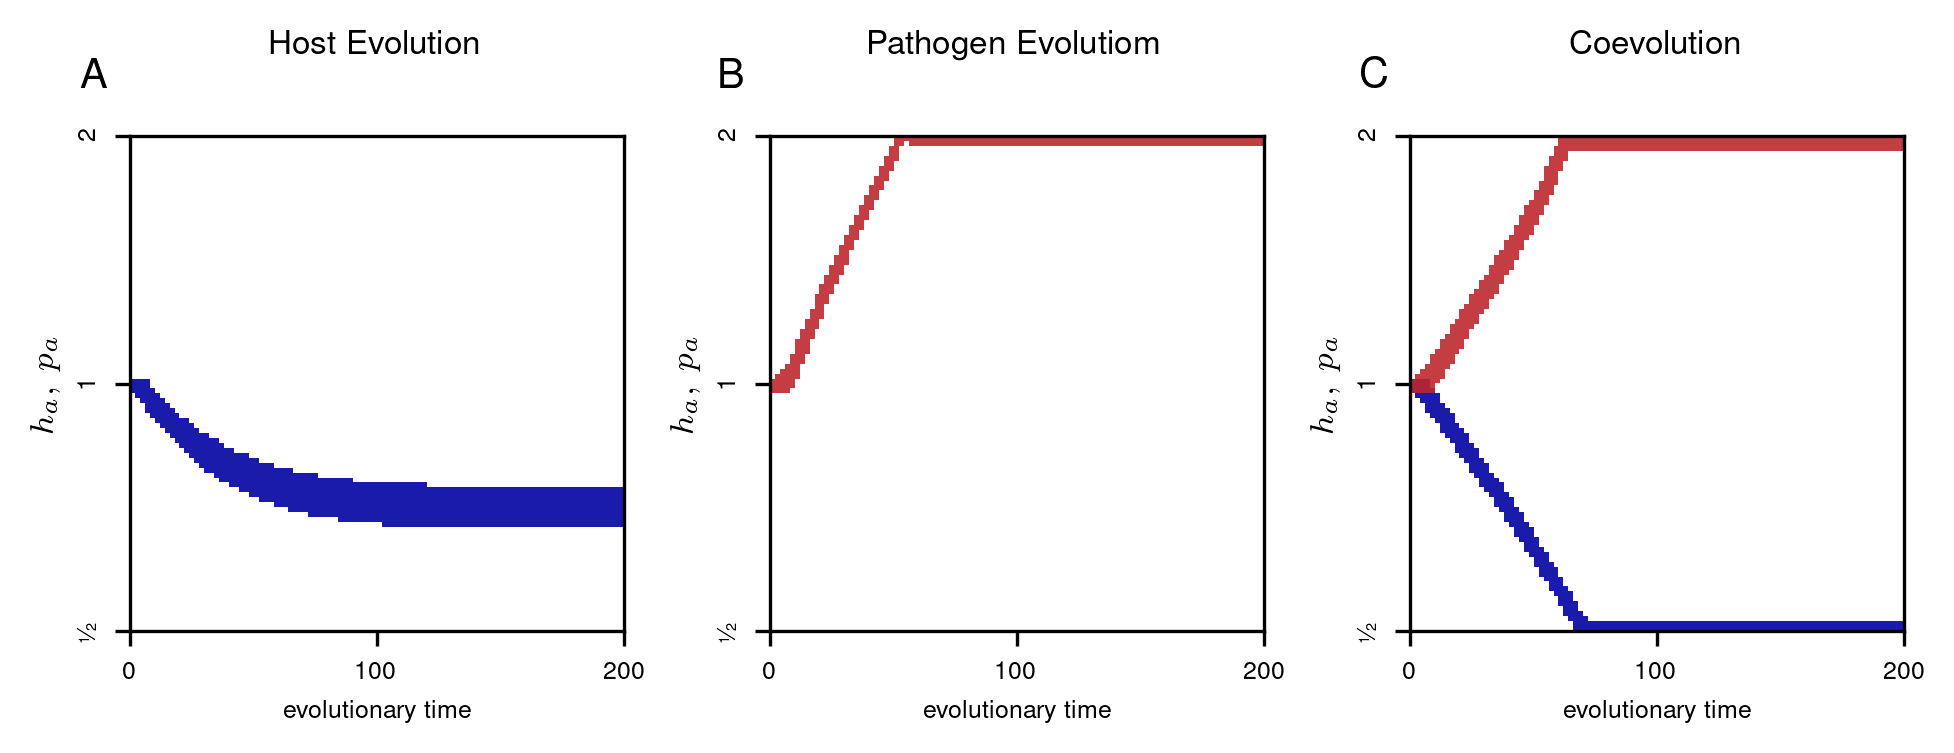

In [4]:
fig, ax = plt.subplots(ncols=3, nrows=1, layout='compressed')

ax[0].imshow(Sa_img_host, alpha=Sa_alpha_host, cmap=s_cmap)
ax[1].imshow(Ia_img_path, alpha=Ia_alpha_path, cmap=i_cmap)
ax[2].imshow(Sa_img_coevol, alpha=Sa_alpha_coevol, cmap=s_cmap)
ax[2].imshow(Ia_img_coevol, alpha=Ia_alpha_coevol, cmap=i_cmap)

ax[0].set_title('Host Evolution', fontsize=8, pad=20)
ax[1].set_title('Pathogen Evolutiom', fontsize=8, pad=20)
ax[2].set_title('Coevolution', fontsize=8, pad=20)

def label_x_axis(ax, n_x_ticks = 3):
    x_lim = ax.get_xlim()
    x_ticks = np.linspace(x_lim[0], x_lim[1], n_x_ticks)
    x_tick_labels = np.linspace(0, model_host.N_iter, n_x_ticks)

    ax.set_xticks(x_ticks, x_tick_labels.astype(int))

for axis in ax: 
    axis.yaxis.set_major_locator(matplotlib.ticker.MaxNLocator(nbins=5))
    axis.yaxis.set_major_formatter(matplotlib.ticker.FormatStrFormatter('%.2f'))
    label_x_axis(axis)

    ax_tick_pos = np.linspace(axis.get_ylim()[0], axis.get_ylim()[1], 3)
    ax_tick_labels = [r'\sfrac{1}{2}',r'1',r'2']
    axis.set_yticks(ax_tick_pos, ax_tick_labels, rotation=90)

    axis.set_xlabel(r'evolutionary time')
    axis.set_ylabel(r'$h_a,\ p_a$', fontsize=8)
    axis.set_ylabel(r'$h_a,\ p_a$', fontsize=8)

ax[0].annotate("A", xy=(-0.1, 1.1), xycoords="axes fraction", fontsize=plot_label_size)
ax[1].annotate("B", xy=(-0.1, 1.1), xycoords="axes fraction", fontsize=plot_label_size)
ax[2].annotate("C", xy=(-0.1, 1.1), xycoords="axes fraction", fontsize=plot_label_size)

# Figure 2: Qualitative categories of age-specific coevolutionary outcomes #

In [5]:
params_1 = {'m':0.25, 'z':7, 'mu':0.2, 'juv_trans':False, 'N_iter':200,'S_gtp0':50, 'I_gtp0':50}
params_2 = {'m':0.75, 'z':1, 'mu':0.2, 'juv_trans':False, 'N_iter':200,'S_gtp0':50, 'I_gtp0':50}
params_3 = {'m':0.75, 'z':2, 'mu':0.2, 'juv_trans':False, 'N_iter':200,'S_gtp0':60, 'I_gtp0':60}

model_1 = ModelAnalysis(mode='coevol', **params_1)
model_2 = ModelAnalysis(mode='coevol', **params_2)
model_3 = ModelAnalysis(mode='coevol', **params_3)

Sa_img_1, Ia_img_1, Sa_alpha_1, Ia_alpha_1 = make_image(model_1.Sa, model_1.Ia)
Sa_img_2, Ia_img_2, Sa_alpha_2, Ia_alpha_2 = make_image(model_2.Sa, model_2.Ia)
Sa_img_3, Ia_img_3, Sa_alpha_3, Ia_alpha_3 = make_image(model_3.Sa, model_3.Ia)

Text(-0.1, 1.1, 'C')

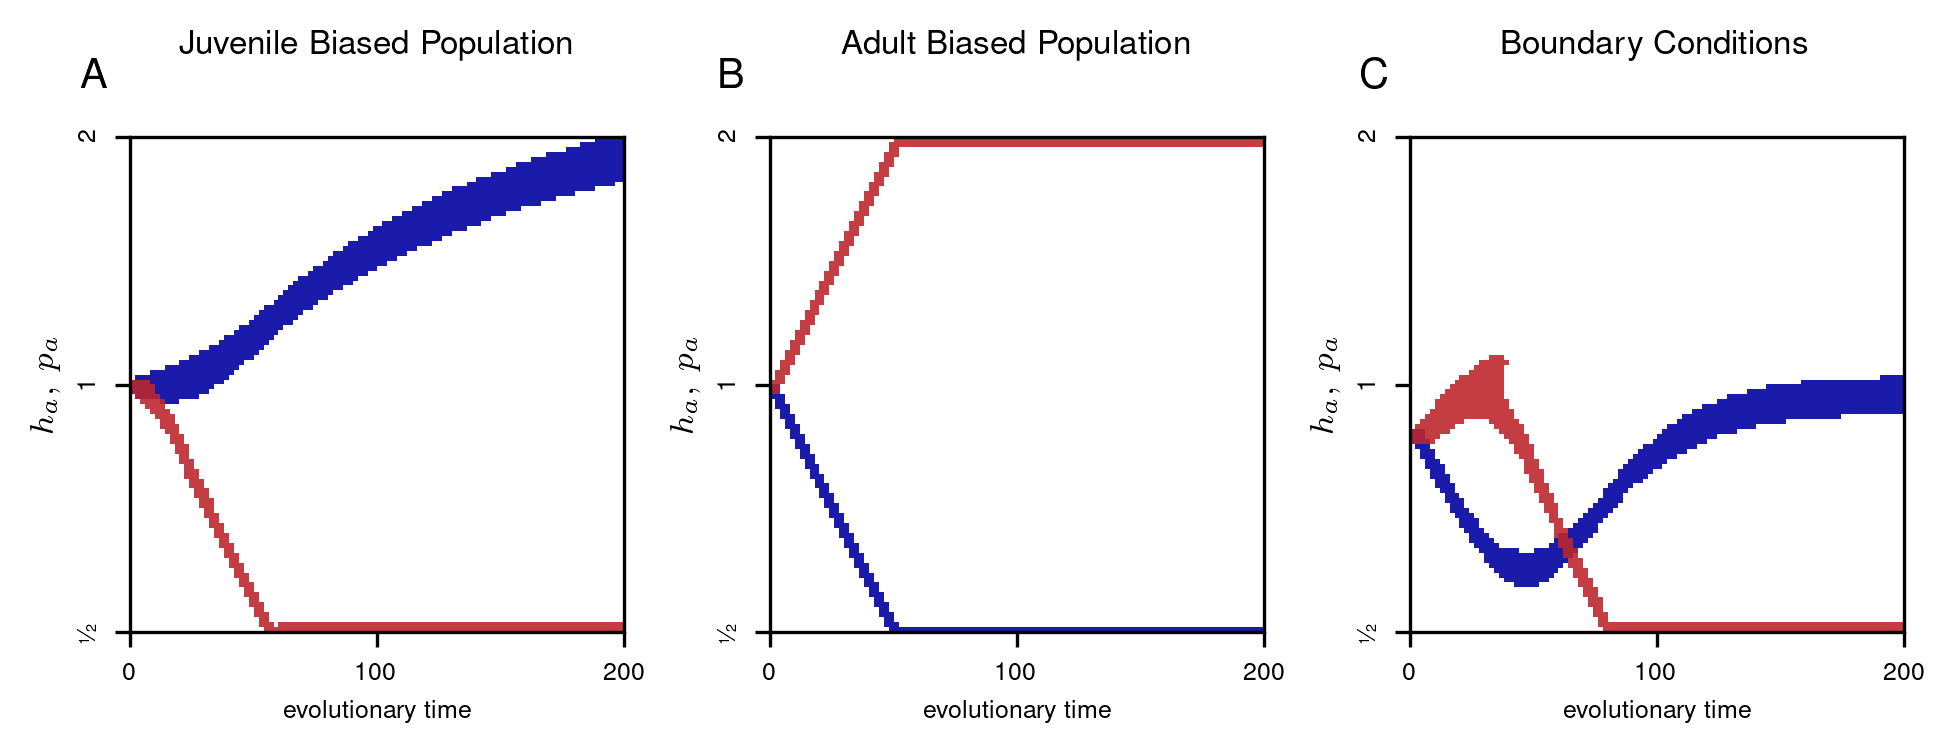

In [6]:
fig, ax = plt.subplots(ncols=3, nrows=1, layout='compressed')

ax[0].imshow(Sa_img_1, alpha=Sa_alpha_1, cmap=s_cmap)
ax[0].imshow(Ia_img_1, alpha=Ia_alpha_1, cmap=i_cmap)
ax[1].imshow(Sa_img_2, alpha=Sa_alpha_2, cmap=s_cmap)
ax[1].imshow(Ia_img_2, alpha=Ia_alpha_2, cmap=i_cmap)
ax[2].imshow(Sa_img_3, alpha=Sa_alpha_3, cmap=s_cmap)
ax[2].imshow(Ia_img_3, alpha=Ia_alpha_3, cmap=i_cmap)

ax[0].set_title('Juvenile Biased Population', fontsize=8, pad=20)
ax[1].set_title('Adult Biased Population', fontsize=8, pad=20)
ax[2].set_title('Boundary Conditions', fontsize=8, pad=20)

def label_x_axis(ax, n_x_ticks = 3):
    x_lim = ax.get_xlim()
    x_ticks = np.linspace(x_lim[0], x_lim[1], n_x_ticks)
    x_tick_labels = np.linspace(0, model_1.N_iter, n_x_ticks)

    ax.set_xticks(x_ticks, x_tick_labels.astype(int))

for axis in ax: 
    axis.yaxis.set_major_locator(matplotlib.ticker.MaxNLocator(nbins=5))
    axis.yaxis.set_major_formatter(matplotlib.ticker.FormatStrFormatter('%.2f'))
    label_x_axis(axis)

    ax_tick_pos = np.linspace(axis.get_ylim()[0], axis.get_ylim()[1], 3)
    ax_tick_labels = [r'\sfrac{1}{2}',r'1',r'2']
    axis.set_yticks(ax_tick_pos, ax_tick_labels, rotation=90)

    axis.set_xlabel(r'evolutionary time')
    axis.set_ylabel(r'$h_a,\ p_a$', fontsize=8)
    axis.set_ylabel(r'$h_a,\ p_a$', fontsize=8)

ax[0].annotate("A", xy=(-0.1, 1.1), xycoords="axes fraction", fontsize=plot_label_size)
ax[1].annotate("B", xy=(-0.1, 1.1), xycoords="axes fraction", fontsize=plot_label_size)
ax[2].annotate("C", xy=(-0.1, 1.1), xycoords="axes fraction", fontsize=plot_label_size)

# Figure 3: Maturation rate and adult resitance advantage affect host and pathogen evolutionary and coevolutionary outcomes #

In [3]:
host_path = 'data/default_init_50_host.p'
path_path = 'data/default_init_50_path.p'
coevol_path_50 = 'data/default_init_50_coevol.p'
coevol_path_60 = 'data/default_init_60_coevol.p'

host_raster = RasterAnalysis(host_path, arg_x='m', arg_y='z')
path_raster = RasterAnalysis(path_path, arg_x='m', arg_y='z')
coevol_raster_50 = RasterAnalysis(coevol_path_50, arg_x='m', arg_y='z')
coevol_raster_60 = RasterAnalysis(coevol_path_60, arg_x='m', arg_y='z')

/tmp/ipykernel_478121/358313825.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  cbar.ax.set_xticklabels(['Low Juvenile Transmission \n High Adult Transmission', 'High Juvenile Transmission \n Low Adult Transmission'])


Text(-0.1, 1.1, 'D')

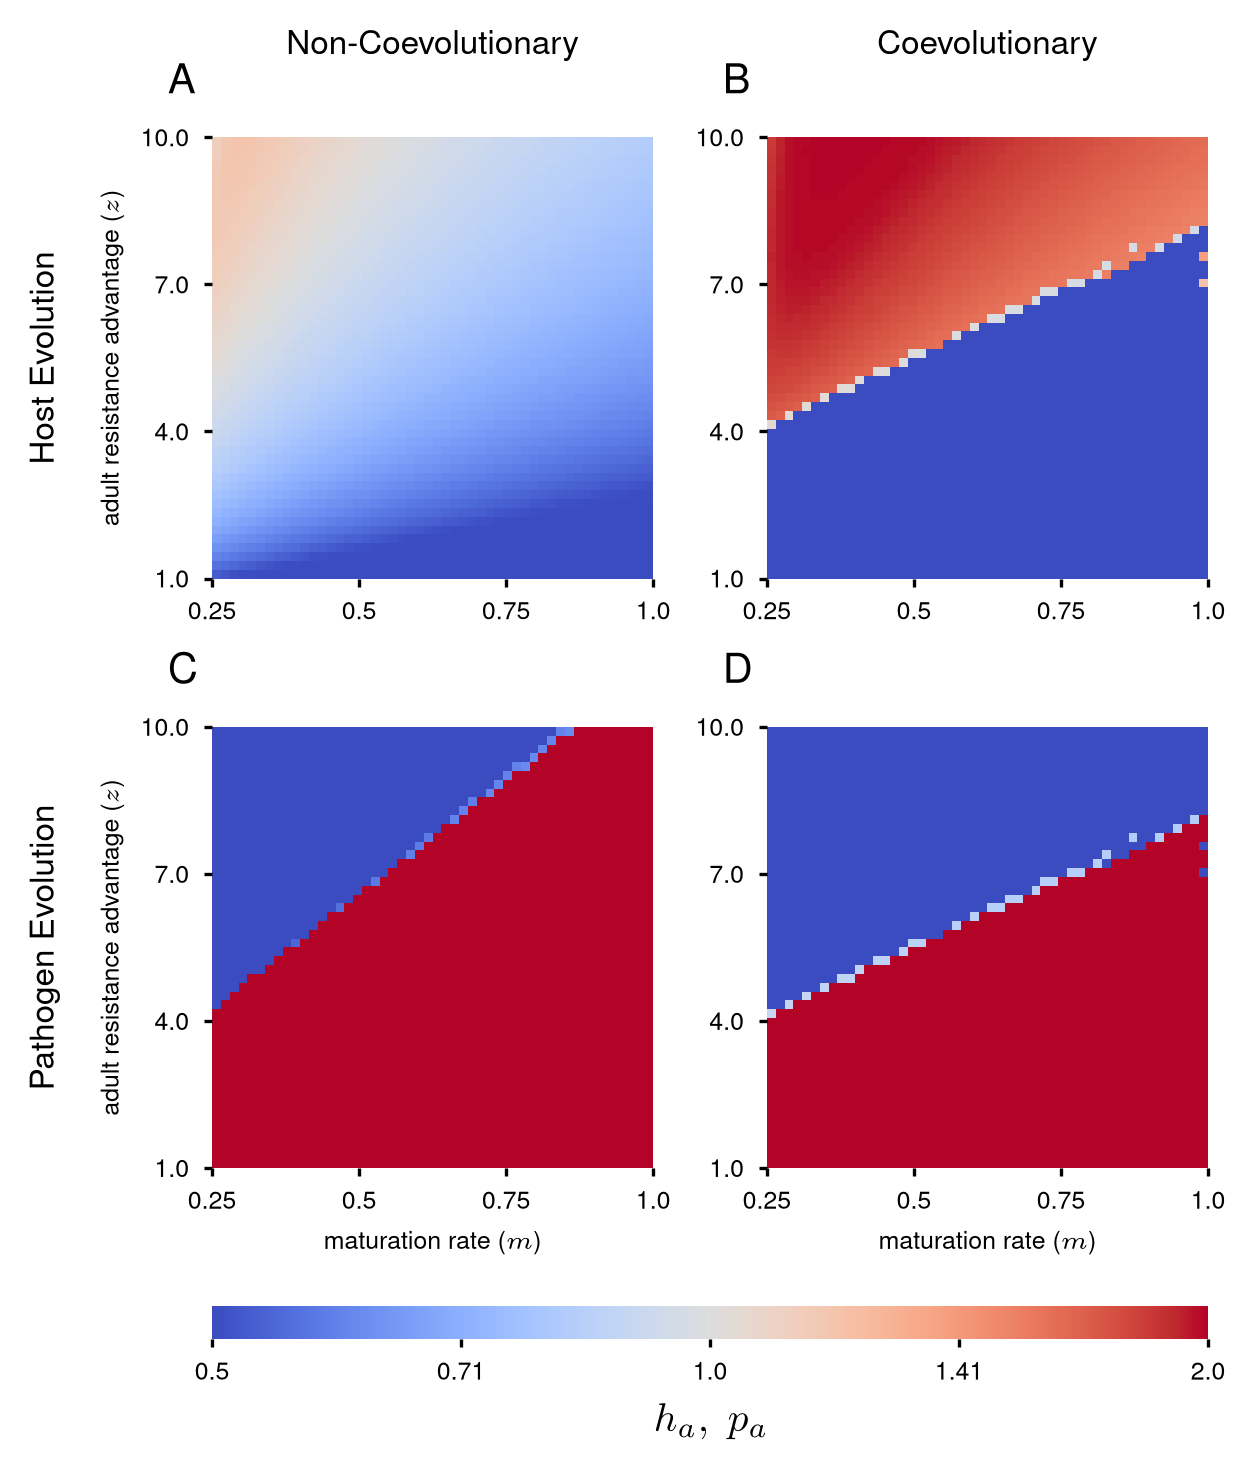

In [4]:
fig, ax = plt.subplots(ncols=2, nrows=2, layout='compressed')

S_host, I_host, = host_raster.evol_plot()
S_path, I_path, = path_raster.evol_plot()
S_coevol_50, I_coevol_50, = coevol_raster_50.evol_plot()
S_coevol_60, I_coevol_60, = coevol_raster_60.evol_plot()

plot = ax[0,0].imshow(99 - S_host, cmap='coolwarm', vmin=0, vmax=99)
ax[1,0].imshow(99 - I_path, cmap='coolwarm', vmin=0, vmax=99)

ax[0,1].imshow(99 - S_coevol_50, cmap='coolwarm', vmin=0, vmax=99)
ax[1,1].imshow(99 - I_coevol_50, cmap='coolwarm', vmin=0, vmax=99)

for axis in ax.reshape(-1):
    axis.invert_yaxis()
    axis.set_frame_on(False)
    axis.tick_params('both', length=2)

coevol_raster_60.label_axes(ax[0,0], (4, 4), label_x=False, label_y=True)
coevol_raster_60.label_axes(ax[1,0], (4, 4), label_y=True, x_string=r'maturation rate ($m$)')
coevol_raster_50.label_axes(ax[0,1], (4, 4), label_x=False, label_y=False)
coevol_raster_50.label_axes(ax[1,1], (4, 4), label_y=False, x_string=r'maturation rate ($m$)')

ax[0,0].set_title('Non-Coevolutionary', pad=20, fontsize=8)
ax[0,1].set_title('Coevolutionary', pad=20, fontsize=8)

ax[0,0].annotate('Host Evolution', xy=(0, 0.5), xytext=(-40,0), xycoords='axes fraction', textcoords='offset points', ha='center', va='center', rotation=90, fontsize=8)
ax[1,0].annotate('Pathogen Evolution', xy=(0, 0.5), xytext=(-40,0), xycoords='axes fraction', textcoords='offset points', ha='center', va='center', rotation=90, fontsize=8)

cbar = fig.colorbar(plot, ax=ax[:], location='bottom', aspect=30)
cbar.ax.set_xticklabels(['Low Juvenile Transmission \n High Adult Transmission', 'High Juvenile Transmission \n Low Adult Transmission'])
cbar.ax.tick_params(axis='both', which='both', length=2)
cbar.ax.set_xticks(np.linspace(0, 99, 5))
cbar.ax.set_xticklabels(np.round(np.logspace(-1, 1, 5, base=2), 2))
cbar.set_label(r'$h_a,\ p_a$', fontsize=10)
cbar.outline.set_visible(False)

ax[0,0].annotate("A", xy=(-0.1, 1.1), xycoords="axes fraction", fontsize=plot_label_size)
ax[0,1].annotate("B", xy=(-0.1, 1.1), xycoords="axes fraction", fontsize=plot_label_size)
ax[1,0].annotate("C", xy=(-0.1, 1.1), xycoords="axes fraction", fontsize=plot_label_size)
ax[1,1].annotate("D", xy=(-0.1, 1.1), xycoords="axes fraction", fontsize=plot_label_size)


# Figure 4: Coevolutionary outcomes depend on initial conditions #

In [3]:
path_mu1z5 = 'data/initial_conds_mu1z5_coevol.p'
path_mu2z1 = 'data/initial_conds_mu2z1_coevol.p'
path_mu2z5 = 'data/initial_conds_mu2z5_coevol.p'

mu1z5 = RasterAnalysis(path_mu1z5, arg_x='S_gtp0', arg_y='I_gtp0')
mu2z1 = RasterAnalysis(path_mu2z1, arg_x='S_gtp0', arg_y='I_gtp0')
mu2z5 = RasterAnalysis(path_mu2z5, arg_x='S_gtp0', arg_y='I_gtp0')

In [4]:
#Generate date for evolutionary simulation figures, for branching example use 'm':0.93, 'z':10
params_1 = {'m':0.5, 'z':3, 'mu':0.2, 'juv_trans':False, 'N_iter':200,'S_gtp0':40, 'I_gtp0':40}
params_2 = {'m':0.5, 'z':3, 'mu':0.2, 'juv_trans':False, 'N_iter':200,'S_gtp0':60, 'I_gtp0':60}

model_1 = ModelAnalysis(mode='coevol', **params_1)
model_2 = ModelAnalysis(mode='coevol', **params_2)

In [5]:
def plot_transition(raster):
    resA = raster.models[0].resA * raster.models[0].z
    infA = raster.models[0].infA / raster.models[0].beta
    S0_inds = np.arange(0, 99, 2)
    I0_inds = np.arange(0, 99, 2)
    S0_vals = resA[S0_inds]
    I0_vals = infA[I0_inds]

    S, I = raster.evol_plot()
    vals = (np.min(I), np.max(I))
    
    S_vals = []
    I_vals = []

    base_val = np.argmin(np.abs(vals - I[0, 0]))

    for i in range(I.shape[0]):
        for j in range(I.shape[1]):
            if np.argmin(np.abs(vals - I[j, i])) != base_val:
                S_vals.append(S0_vals[i])
                I_vals.append(I0_vals[j])
                break;

    return S_vals, I_vals

Text(-0.1, 1.1, 'D')

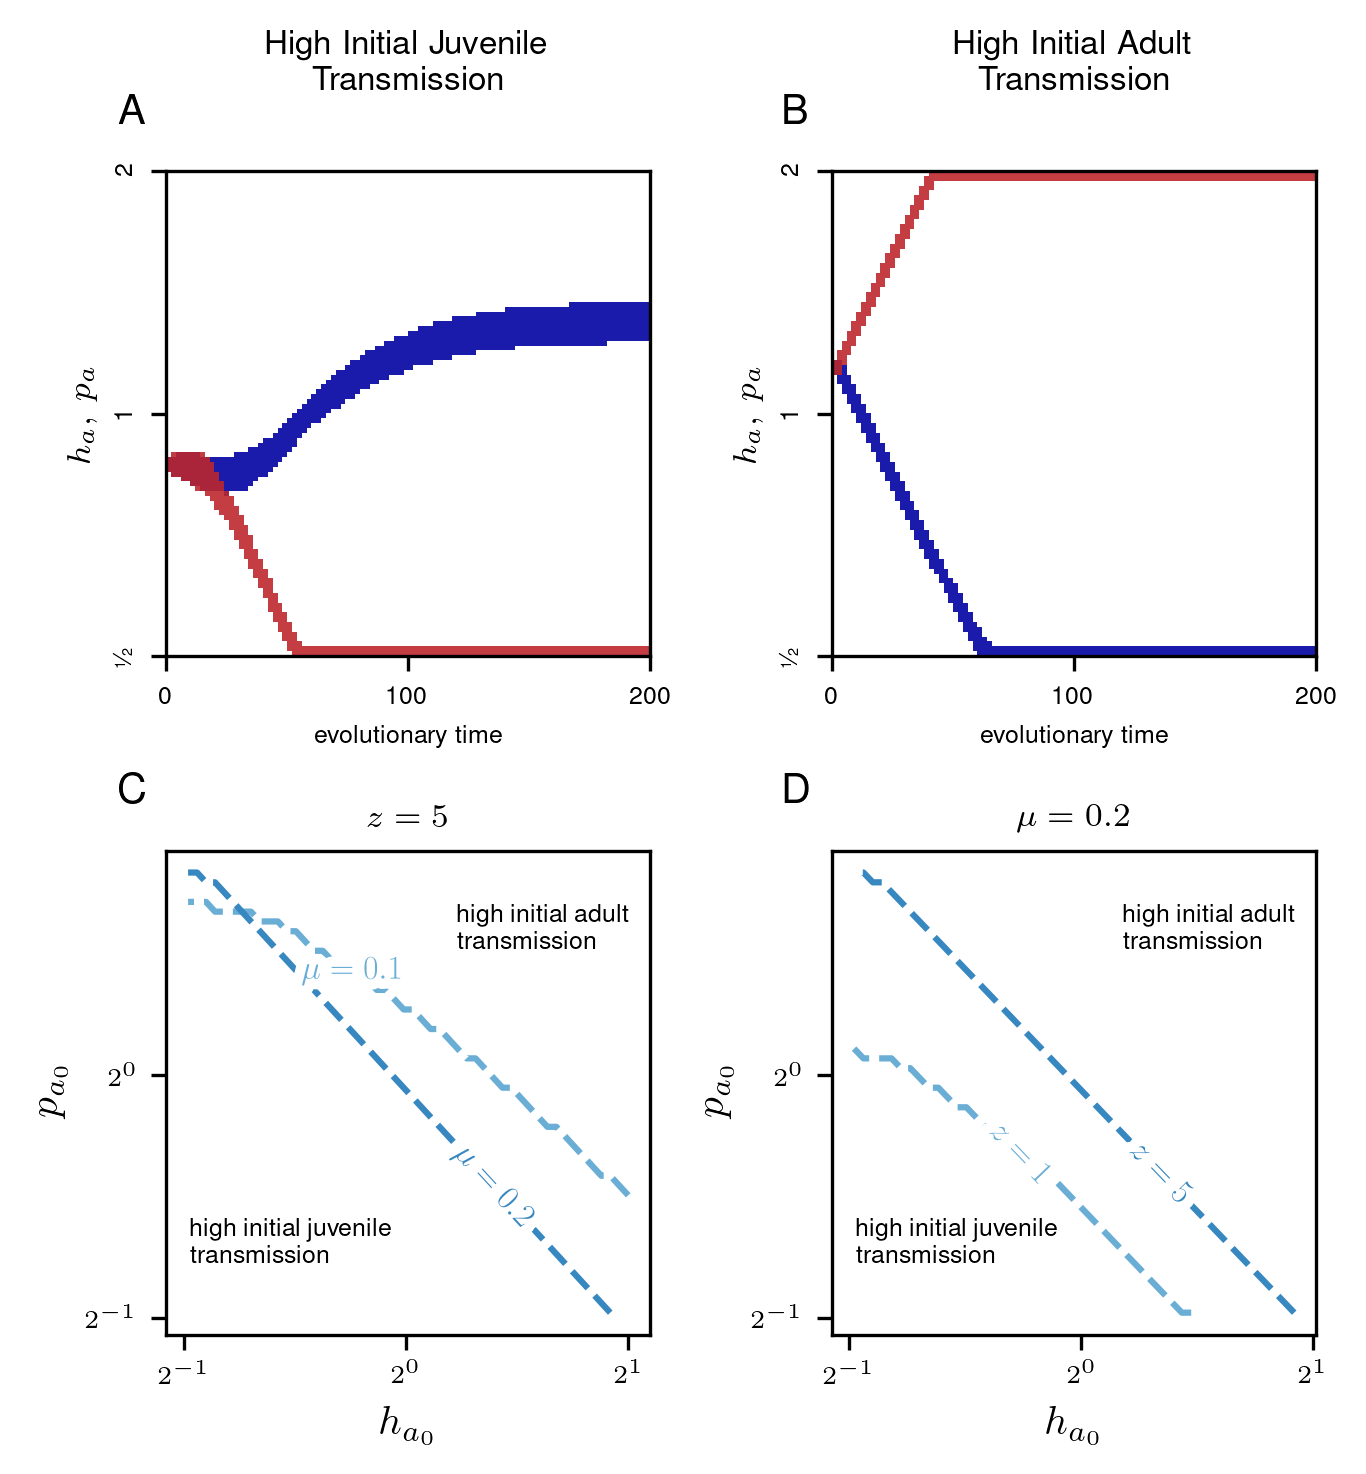

In [6]:
from labellines import labelLine, labelLines

fig, ax = plt.subplots(ncols=2, nrows=2, layout='compressed')

cmap = matplotlib.colormaps['Blues']
colors = cmap(np.linspace(0, 1, 7))

S_mu1z5, I_mu1z5 = plot_transition(mu1z5)
S_mu2z1, I_mu2z1 = plot_transition(mu2z1)
S_mu2z5, I_mu2z5 = plot_transition(mu2z5)

Sa_img_1, Ia_img_1, Sa_alpha_1, Ia_alpha_1 = make_image(model_1.Sa, model_1.Ia)
Sa_img_2, Ia_img_2, Sa_alpha_2, Ia_alpha_2 = make_image(model_2.Sa, model_2.Ia)

ax[0,0].imshow(Sa_img_2, alpha=Sa_alpha_2, cmap=s_cmap)
ax[0,0].imshow(Ia_img_2, alpha=Ia_alpha_2, cmap=i_cmap)
ax[0,1].imshow(Sa_img_1, alpha=Sa_alpha_1, cmap=s_cmap)
ax[0,1].imshow(Ia_img_1, alpha=Ia_alpha_1, cmap=i_cmap)

def label_x_axis(ax, n_x_ticks = 3):
    x_lim = ax.get_xlim()
    x_ticks = np.linspace(x_lim[0], x_lim[1], n_x_ticks)
    x_tick_labels = np.linspace(0, model_1.N_iter, n_x_ticks)

    ax.set_xticks(x_ticks, x_tick_labels.astype(int))

for axis in ax[0,:]: 
    axis.yaxis.set_major_locator(matplotlib.ticker.MaxNLocator(nbins=5))
    axis.yaxis.set_major_formatter(matplotlib.ticker.FormatStrFormatter('%.2f'))
    label_x_axis(axis)

    ax_tick_pos = np.linspace(axis.get_ylim()[0], axis.get_ylim()[1], 3)
    ax_tick_labels = [r'\sfrac{1}{2}',r'1',r'2']
    axis.set_yticks(ax_tick_pos, ax_tick_labels, rotation=90)

    axis.set_xlabel(r'evolutionary time')
    axis.set_ylabel(r'$h_a,\ p_a$', fontsize=8)

ax[0,0].set_title('High Initial Juvenile\nTransmission', fontsize=8, pad=20)
ax[0,1].set_title('High Initial Adult\nTransmission', fontsize=8, pad=20)

ax[1,0].set_title(r'$z=5$', fontsize=8)
ax[1,1].set_title(r'$\mu=0.2$', fontsize=8)

ax[1,0].loglog(S_mu1z5, I_mu1z5, label=r'$\mu=0.1$', c=colors[3], linestyle='dashed', base=2)
ax[1,0].loglog(S_mu2z5, I_mu2z5, label=r'$\mu=0.2$', c=colors[4], linestyle='dashed', base=2)
labelLines(ax[1,0].get_lines(), zorder=2.5, fontsize=8) 

ax[1,1].loglog(S_mu2z1, I_mu2z1, label=r'$z=1$', c=colors[3], linestyle='dashed', base=2)
ax[1,1].loglog(S_mu2z5, I_mu2z5, label=r'$z=5$', c=colors[4], linestyle='dashed', base=2)
labelLines(ax[1,1].get_lines(), zorder=2.5, fontsize=8) 

for axis in ax[1,:]: 
    axis.set_xlabel(r'$h_{a_0}$', fontsize=10)
    axis.set_ylabel(r'$p_{a_0}$', fontsize=10)

    axis.annotate('high initial juvenile\ntransmission',(0.05,0.15), xycoords='axes fraction', fontsize=6)
    axis.annotate('high initial adult\ntransmission', (0.6,0.8), xycoords='axes fraction', fontsize=6)

ax[0,0].annotate("A", xy=(-0.1, 1.1), xycoords="axes fraction", fontsize=plot_label_size)
ax[0,1].annotate("B", xy=(-0.1, 1.1), xycoords="axes fraction", fontsize=plot_label_size)
ax[1,0].annotate("C", xy=(-0.1, 1.1), xycoords="axes fraction", fontsize=plot_label_size)
ax[1,1].annotate("D", xy=(-0.1, 1.1), xycoords="axes fraction", fontsize=plot_label_size)

# Figure 5: Evolutionary Dynamics can impact the overall distribution of age-spcific transmission #

In [2]:
host_path = 'data/default_init_50_host.p'
path_path = 'data/default_init_50_path.p'
coevol_path_50 = 'data/default_init_50_coevol.p'
coevol_path_60 = 'data/default_init_60_coevol.p'

host_raster = RasterAnalysis(host_path, arg_x='m', arg_y='z')
path_raster = RasterAnalysis(path_path, arg_x='m', arg_y='z')
coevol_raster_50 = RasterAnalysis(coevol_path_50, arg_x='m', arg_y='z')
coevol_raster_60 = RasterAnalysis(coevol_path_60, arg_x='m', arg_y='z')

Text(-0.1, 1.1, 'F')

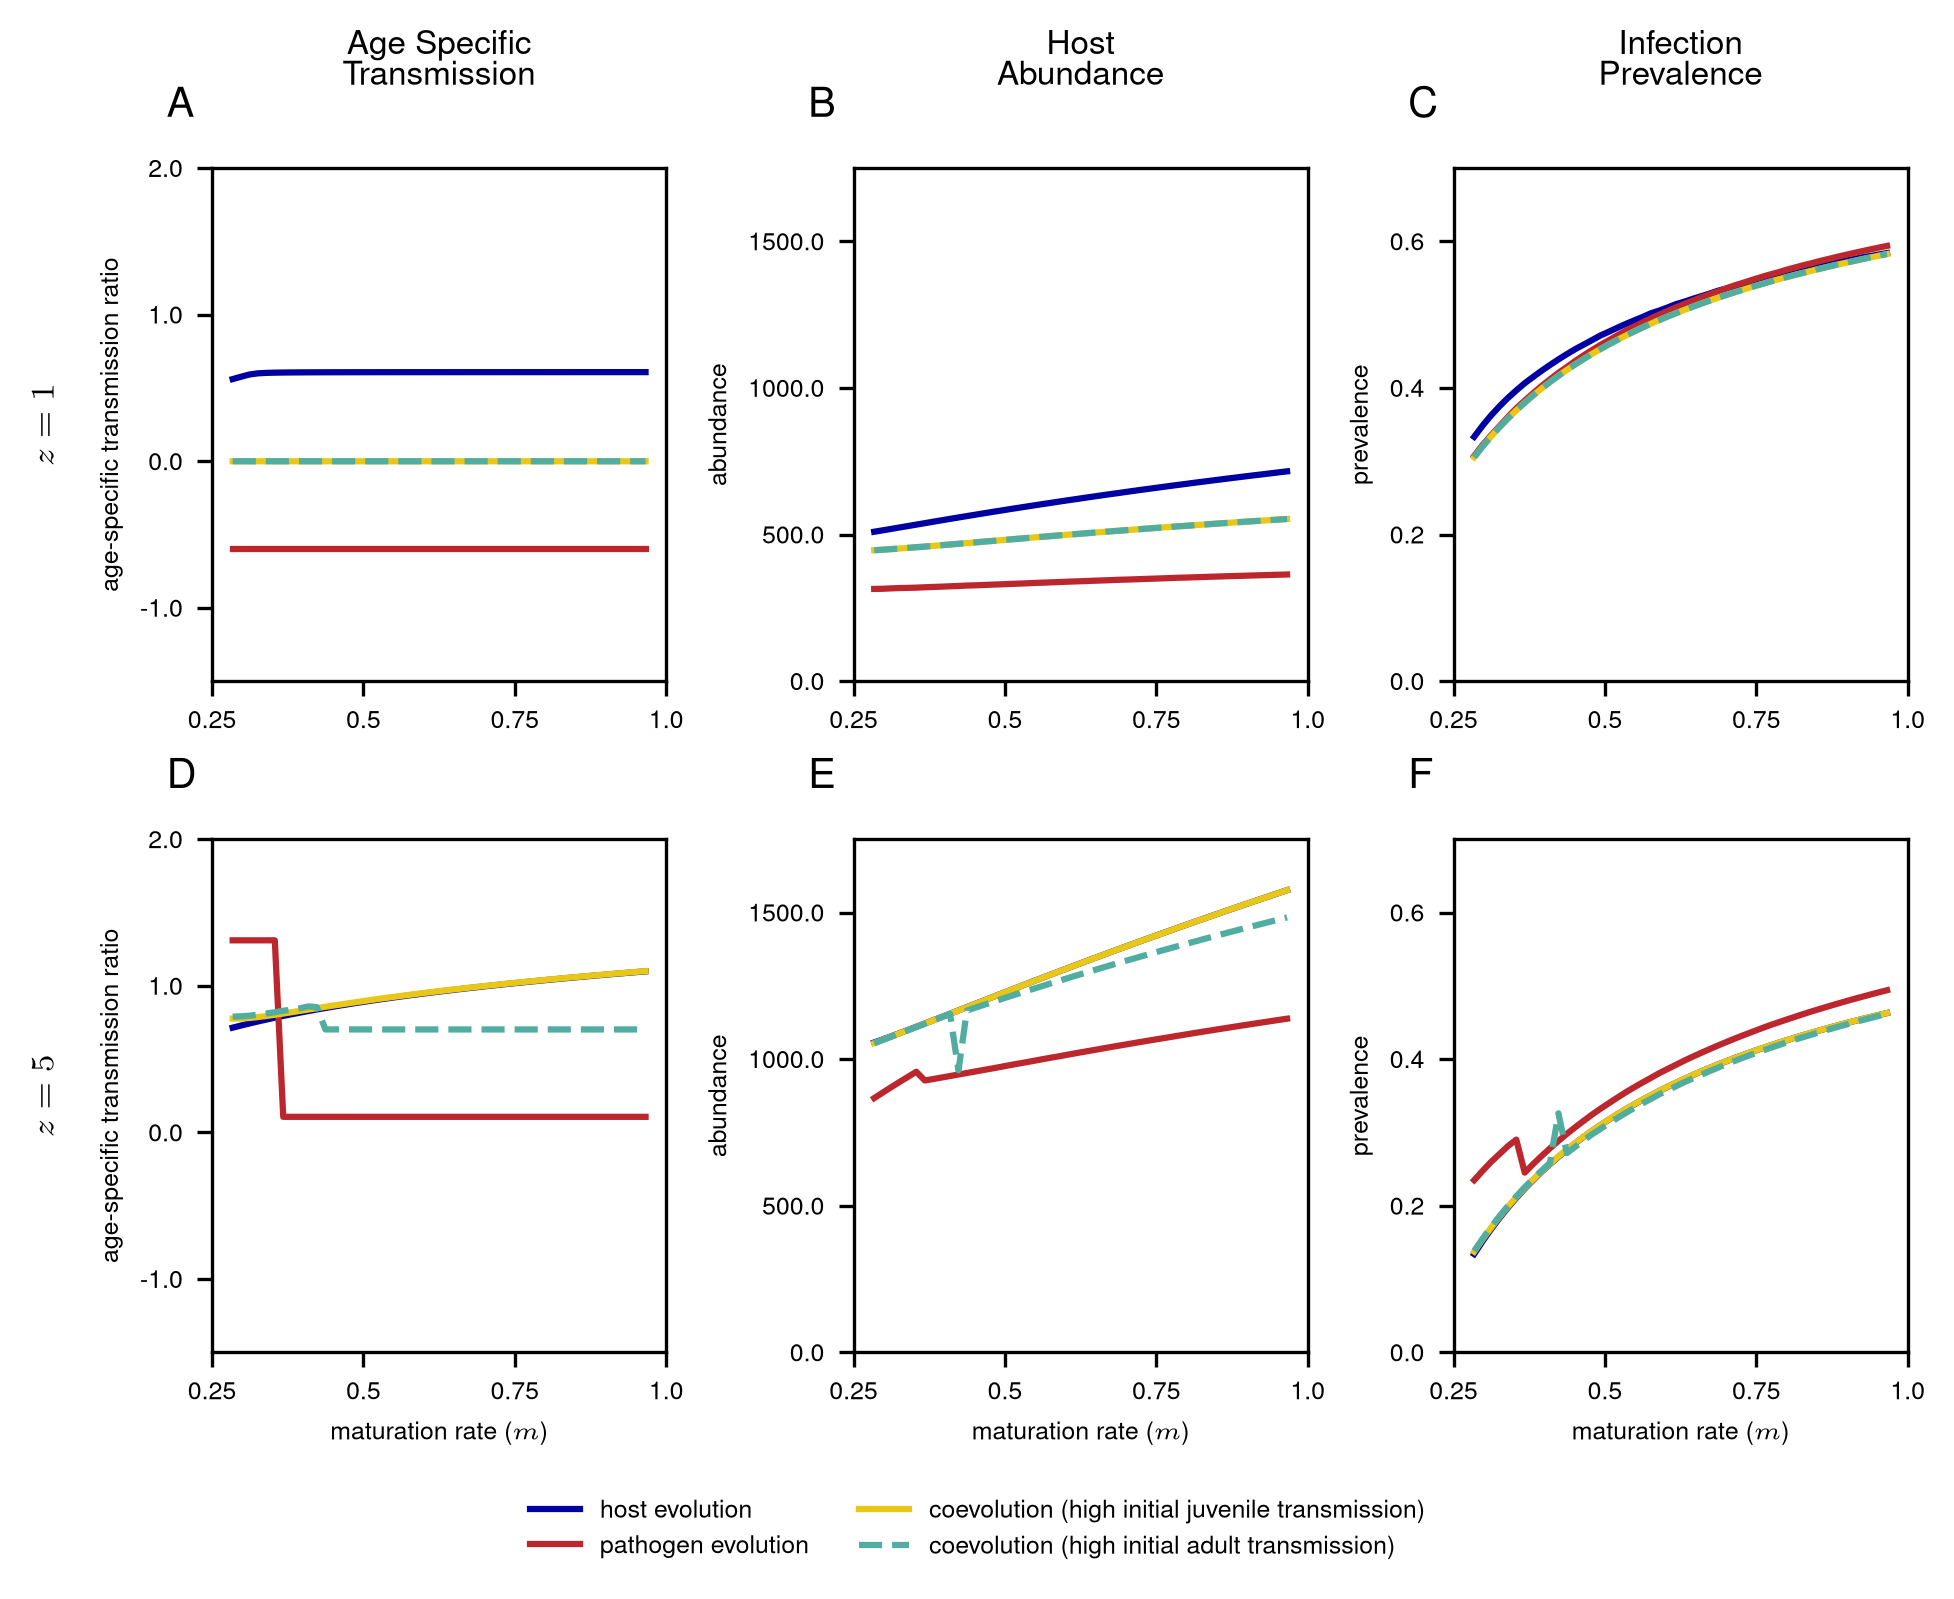

In [8]:
fig, ax = plt.subplots(ncols=3, nrows=2, layout='compressed')

z_1 = 1
z_2 = 5

ind_1 = np.argmin((coevol_raster_60.y_vals - z_1)**2)
ind_2 = np.argmin((coevol_raster_60.y_vals - z_2)**2)

inds = [ind_1, ind_2]

def label_xaxis(ax, n_ticks=4):
    m_vals = coevol_raster_60.x_vals
    x_lim = ax.get_xlim()

    x_ticks = np.linspace(x_lim[0], x_lim[1], n_ticks)
    x_tick_labels = np.round(np.linspace(np.min(m_vals), np.max(m_vals), n_ticks), 3)
    
    ax.set_xticks(x_ticks, x_tick_labels)

betaj_host, betaa_host = host_raster.mean_transmission()
betaj_path, betaa_path = path_raster.mean_transmission()
betaj_coevol_60, betaa_coevol_60 = coevol_raster_60.mean_transmission()
betaj_coevol_50, betaa_coevol_50 = coevol_raster_50.mean_transmission()

host_ratio = np.log10(betaj_host / betaa_host)
path_ratio = np.log10(betaj_path / betaa_path)
coevol_ratio_60 = np.log10(betaj_coevol_60 / betaa_coevol_60)
coevol_ratio_50 = np.log10(betaj_coevol_50 / betaa_coevol_50)


Sj_h, Sa_h, Ij_h, Ia_h = host_raster.abundance()
Sj_p, Sa_p, Ij_p, Ia_p = path_raster.abundance()
Sj_60c, Sa_60c, Ij_60c, Ia_60c = coevol_raster_60.abundance()
Sj_50c, Sa_50c, Ij_50c, Ia_50c = coevol_raster_50.abundance()


for i in range(2):
    ax[i,0].plot(host_ratio[inds[i],:], label='host evolution', color=host_color)
    ax[i,0].plot(path_ratio[inds[i],:], label='pathogen evolution', color=path_color)
    ax[i,0].plot(coevol_ratio_60[inds[i],:], label='coevolution (high initial juvenile transmission)', color=coevol_color)
    ax[i,0].plot(coevol_ratio_50[inds[i],:], label='coevolution (high initial adult transmission)', color=coevol_color_2, linestyle='--')

    ax[i,1].plot((Sj_h+Sa_h+Ij_h+Ia_h)[inds[i],:], label='host evolution', color=host_color)
    ax[i,1].plot((Sj_p+Sa_p+Ij_p+Ia_p)[inds[i],:], label='pathogen evolution', color=path_color)
    ax[i,1].plot((Sj_60c+Sa_60c+Ij_60c+Ia_60c)[inds[i],:], label='coevolution (high initial juvenile)', color=coevol_color)
    ax[i,1].plot((Sj_50c+Sa_50c+Ij_50c+Ia_50c)[inds[i],:], label='coevolution (high initial adult)', color=coevol_color_2, linestyle='--')

    ax[i,2].plot(((Ij_h+Ia_h)/(Sj_h+Sa_h+Ij_h+Ia_h))[inds[i],:], label='host evolution', color=host_color)
    ax[i,2].plot(((Ij_p+Ia_p)/(Sj_p+Sa_p+Ij_p+Ia_p))[inds[i],:], label='pathogen evolution', color=path_color)
    ax[i,2].plot(((Ij_60c+Ia_60c)/(Sj_60c+Sa_60c+Ij_60c+Ia_60c))[inds[i],:], label='coevolution (high initial juvenile)', color=coevol_color)
    ax[i,2].plot(((Ij_50c+Ia_50c)/(Sj_50c+Sa_50c+Ij_50c+Ia_50c))[inds[i],:], label='coevolution (high initial adult)', color=coevol_color_2, linestyle='--')

    ax[i,0].set_ylim(-1.5, 2)
    ax[i,1].set_ylim(0, 1750)
    ax[i,2].set_ylim(0, 0.7)

    ax[i,0].set_ylabel('age-specific transmission ratio')
    ax[i,1].set_ylabel('abundance')
    ax[i,2].set_ylabel('prevalence')


for axis in ax.reshape(-1):
    axis.yaxis.set_major_locator(matplotlib.ticker.MaxNLocator(nbins=4))
    axis.yaxis.set_major_formatter(matplotlib.ticker.FormatStrFormatter('%.1f'))

ax[0,0].annotate(r'$z=1$', xy=(0, 0.5), xytext=(-40,0), xycoords='axes fraction', textcoords='offset points', ha='center', va='center', rotation=90, fontsize=8)
ax[1,0].annotate(r'$z=5$', xy=(0, 0.5), xytext=(-40,0), xycoords='axes fraction', textcoords='offset points', ha='center', va='center', rotation=90, fontsize=8)

ax[0,0].set_title('Age Specific\nTransmission', fontsize=8, pad=20)
ax[0,1].set_title('Host\nAbundance', fontsize=8, pad=20)
ax[0,2].set_title('Infection\nPrevalence', fontsize=8, pad=20)

[ax[1,i].set_xlabel(r'maturation rate ($m$)') for i in range(3)]

for axis in ax.reshape(-1): label_xaxis(axis)

lines, labels = ax[0,0].get_legend_handles_labels()
fig.legend(lines, labels, ncol=2, loc='center', bbox_to_anchor=(0.5, -0.05), frameon=False, fontsize=6)

ax[0,0].annotate("A", xy=(-0.1, 1.1), xycoords="axes fraction", fontsize=plot_label_size)
ax[0,1].annotate("B", xy=(-0.1, 1.1), xycoords="axes fraction", fontsize=plot_label_size)
ax[0,2].annotate("C", xy=(-0.1, 1.1), xycoords="axes fraction", fontsize=plot_label_size)
ax[1,0].annotate("D", xy=(-0.1, 1.1), xycoords="axes fraction", fontsize=plot_label_size)
ax[1,1].annotate("E", xy=(-0.1, 1.1), xycoords="axes fraction", fontsize=plot_label_size)
ax[1,2].annotate("F", xy=(-0.1, 1.1), xycoords="axes fraction", fontsize=plot_label_size)